In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold
from joblib import Parallel, delayed, dump, load
from extracter import *
from fitting_model import *
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)

In [2]:
fold_nums = [0,1,2,3,4]
num_ft = 36
rep = 3
all_targets = {}
all_states = {}
real_targets = {}
gamma='10' #.1
column_name = 'PQ-15'


all_targets, all_states, real_targets = speech_5folds_extracter(column_name, gamma = gamma,rep = rep, fold_nums = fold_nums, num_ft=num_ft)

In [3]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from trainer import *
train_points = 398
delay_points = 2
observation = train_points + delay_points
results = {}
errors = []
holder = []

errors = train(all_targets, all_states, real_targets, train_points = train_points, delay_points = delay_points, fold_nums=fold_nums, num_ft=num_ft)
errors

  [0.16, 0.12, 0.14, 0.16, 0.17]


[0.16, 0.12, 0.14, 0.16, 0.17]

In [4]:
gammas = ['05', '10', '15', '20', '25']
reps = [1,3]
tau = 15
fold_nums = [0,1,2,3,4]
num_ft = 36
performance= {}
column_name = 'PQ-10'
train_points = 395
delay_points = 5
rep1_errors=[]
rep3_errors=[]

for gamma in gammas:
    all_targets, all_states, real_targets = speech_5folds_extracter(column_name, gamma = gamma,rep = 1, fold_nums = fold_nums, num_ft=num_ft)
    errors = train(all_targets, all_states, real_targets, train_points = train_points, delay_points = delay_points, fold_nums=fold_nums, num_ft=num_ft)
    rep1_errors.append(errors)

    all_targets, all_states, real_targets = speech_5folds_extracter(column_name, gamma = gamma,rep = 3, fold_nums = fold_nums, num_ft=num_ft)
    errors = train(all_targets, all_states, real_targets, train_points = train_points, delay_points = delay_points, fold_nums=fold_nums, num_ft=num_ft)
    rep3_errors.append(errors)

  [0.17, 0.2, 0.25, 0.33, 0.29]
  [0.12, 0.17, 0.21, 0.18, 0.19]
  [0.25, 0.19, 0.24, 0.33, 0.26]
  [0.14, 0.13, 0.14, 0.15, 0.17]
  [0.29, 0.16, 0.26, 0.33, 0.27]
  [0.13, 0.1, 0.17, 0.19, 0.19]
  [0.28, 0.2, 0.26, 0.34, 0.29]
  [0.12, 0.1, 0.18, 0.17, 0.21]
  [0.27, 0.23, 0.22, 0.33, 0.27]
  [0.14, 0.13, 0.21, 0.19, 0.2]


In [5]:
reps = [1, 3]
tau_feature = 0

x = np.arange(len(gammas))

rep1_errors_mean = np.array([np.mean(e) for e in rep1_errors])
rep1_errors_std  = np.array([np.std(e, ddof=1) for e in rep1_errors])

rep3_errors_mean = np.array([np.mean(e) for e in rep3_errors])
rep3_errors_std  = np.array([np.std(e, ddof=1) for e in rep3_errors])


In [6]:
rep1_errors

[[0.17, 0.2, 0.25, 0.33, 0.29],
 [0.25, 0.19, 0.24, 0.33, 0.26],
 [0.29, 0.16, 0.26, 0.33, 0.27],
 [0.28, 0.2, 0.26, 0.34, 0.29],
 [0.27, 0.23, 0.22, 0.33, 0.27]]

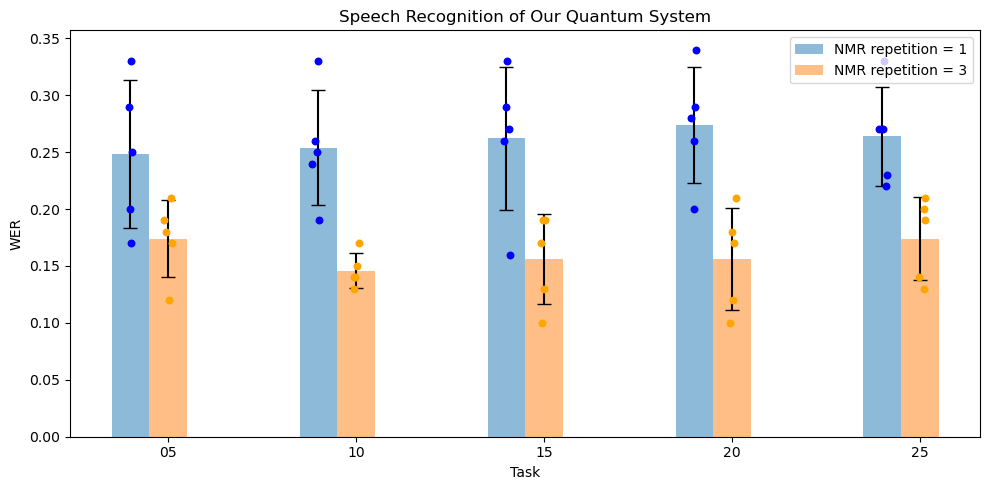

In [7]:
plt.figure(figsize=(10, 5))
width = .2
plt.bar(
    x - width,
    rep1_errors_mean,
    width,
    yerr=rep1_errors_std,
    capsize=5,
    label="NMR repetition = 1",
    alpha=0.5
)

plt.bar(
    x,
    rep3_errors_mean,
    width,
    yerr=rep3_errors_std,
    capsize=5,
    label="NMR repetition = 3",
    alpha=0.5
)

rng = np.random.default_rng(0)

for i, task in enumerate(gammas):

    # QR rep = 1 rolling-window points
    jitter = rng.normal(0, 0.015, size=len(rep1_errors[i]))
    plt.scatter(
        np.full(len(rep1_errors[i]), x[i] - width) + jitter,
        rep1_errors[i],
        s=22,
        zorder=3,
        color="blue"
    )

    # QR rep = 10 rolling-window points
    jitter = rng.normal(0, 0.015, size=len(rep3_errors[i]))
    plt.scatter(
        np.full(len(rep3_errors[i]), x[i]) + jitter,
        rep3_errors[i],
        s=22,
        zorder=3,
        color='orange'
    )

plt.xticks(x, gammas)
plt.ylabel("WER")
plt.xlabel("Task")
plt.title("Speech Recognition of Our Quantum System")
plt.legend()
plt.tight_layout()
plt.show()